<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 1.1</h1>

The aim of this exercise is to verify the correctness of the random number generation algorithm through three different tests: the computational evaluation of the first two moments of the uniform probability distribution in the interval $[0,1)$, the verification of the Central Limit Theorem, and a simulation of the Buffon needle experiment for the estimation of $\pi$.

This first exercise focuses on the computation of the **first two moments of the uniform distribution** and on comparing the numerical results obtained from the random number generator with their theoretical values.


In [2]:
import numpy as np

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import math
import pandas as pd
from scipy.stats import chi2

## First Moment of the Uniform Distribution

The first moment of a probability distribution corresponds to the expected value, or mean, of the associated random variable. For a generic function $r$ distributed according to a uniform probability distribution in the interval $[0,1)$, its expected value is

$$
\langle r \rangle = \int_0^1 r , dr = \frac{1}{2}.
$$

The goal of the simulation is to verify this theoretical result by estimating the integral computationally using a random number generator.

The integral can be estimated by drawing $M$ independent random numbers uniformly distributed in the interval $[0,1)$ and replacing the continuous integral with a finite sum:

$$
\langle r \rangle \simeq \frac{1}{M} \sum_{i=1}^{M} r_i.
$$

Since the estimate is obtained from a finite number of random samples, it is affected by a statistical uncertainty. To study the convergence of the estimate and its statistical fluctuations, we use the **data blocking method**.

### Data blocking

The $M$ measurements are divided into $N$ blocks, each containing $L = {M}/{N}$ measurements.

The average value within the $n$-th block is therefore

$$
\langle r \rangle_n =
\frac{1}{L}
\sum_{i=(n-1)L+1}^{nL} r_i,
\qquad n = 1,\ldots,N.
$$

The block averages provide a sequence of estimates of the quantity of interest.

We then compute the **progressive average**, i.e. the average of the block averages accumulated up to the $n$-th block:

$$
\overline{r}_n =
\frac{1}{n}
\sum_{j=1}^{n} \langle r \rangle_j.
$$

Thus, the progressive average after $n$ blocks corresponds to an estimate obtained using all the measurements contained in the first $n$ blocks. As the number of measurements increases, $\overline{r}_n$ is expected to converge towards the theoretical value

$$
\langle r \rangle = \frac{1}{2}.
$$

### Statistical uncertainty

For each progressive average, we can also estimate its statistical uncertainty which is estimated as

$$
\sigma_{\overline{r}_n} =
\sqrt{
\frac{
\overline{r^2}_n - \overline{r}_n^2
}{n-1}
}.
$$

This quantity represents the uncertainty on the estimate of the mean. As the number of blocks increases, the statistical uncertainty is expected to decrease, indicating an increasingly precise estimate of the first moment.

For this simulation, we use a total of $M = 10^5$ random numbers divided into $N = 100$ blocks, therefore, each block contains $L = {M}/{N} = 10^3$ measurements.


### Implementation of the data blocking method

To perform the calculation of the first and second moments of the uniform distribution,the  framework was equipped with a dedicated `Results` structure and a general data blocking method.

In `Results.h`, the `Results` structure was introduced to store the quantities produced by the different simulation methods. For the data blocking procedure, only the following three members are relevant:

- `ave`, containing the average calculated in each block;
- `ave_prog`, containing the progressive average over the blocks;
- `err_prog`, containing the statistical uncertainty of the progressive average.

The `Simulation` class is initialized through the constructor 

`Simulation(int m, int n) : M(m), N(n), L(m / n) {}`

where $M$ is the total number of generated data and $N$ is the number of blocks. Therefore, each block contains $L$ measurements.

The main function used for the calculation is `Simulation::run`. For each block, $$L$$ random values are generated and the corresponding quantity is accumulated. The block average is then calculated and stored in `ave`. The progressive average is obtained by combining the averages of all blocks considered up to that point.

The statistical uncertainty is evaluated from the progressive averages and their squares according to the standard data blocking estimator discussed above.

The function is designed to be general: the function `func` specifies how the random variable is generated, while `estimator` can be used to calculate a specific quantity from each generated value. The optional `transform` and `error_transform` functions allow the progressive estimate and its uncertainty to be transformed when required. This makes the same implementation suitable for calculating both the first and second moments without duplicating the data blocking procedure.

In [17]:
ave_prog = np.loadtxt('ave_prog.txt')
err_prog = np.loadtxt('err_prog.txt')

In [18]:
M=100000
N=100
L=int(M/N)
x=np.arange(N)
x*=L

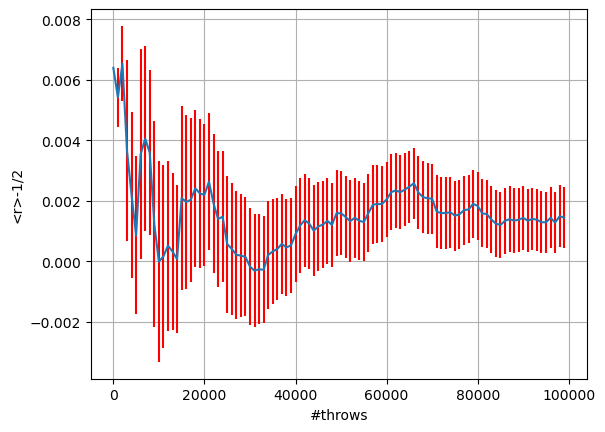

In [24]:
plt.errorbar(x, ave_prog-0.5, yerr=err_prog, ecolor='red')
plt.xlabel('#throws')
plt.ylabel('<r>-1/2')
plt.grid(True)
plt.show()

**Figure 1.** Progressive average of the first moment of the uniform distribution as a function of the number of throws. The calculation was performed using $M = 10^5$ uniformly distributed random numbers, divided into $N = 100$ blocks, with $L = 10^3$ measurements per block.

The progressive average is shown as a function of the number of throws. As the number of blocks increases, the estimate progressively converges towards the theoretical value

$$
\langle r \rangle = \frac{1}{2}.
$$

The progressive average changes from an initial value of $0.50639424$, to a final value of $0.50143761$, approaching the theoretical expectation of $0.5$. At the same time, the statistical uncertainty decrease from $\sim10^{-3}-10^{-2}$ to a value of $0.00101189$.

The small fluctuations around the theoretical value are due to the statistical nature of the random sampling. Overall, the result shows that the random number generator correctly reproduces the expected first moment of the uniform distribution.

### Second Moment

The second central moment of the uniform distribution in the interval $[0,1)$ is

$$
\sigma^2
= \int_0^1 (r-0.5)^2,dr
= \frac{1}{12}.
$$

Similarly with the case of $r$ we compute the progressive average of $(r-0.5)^2$ and compare it with the theoretical value ${1}/{12}$.


In [20]:
ave_prog_err=np.loadtxt('ave_prog_err.txt')
err_prog_err=np.loadtxt('err_prog_err.txt')

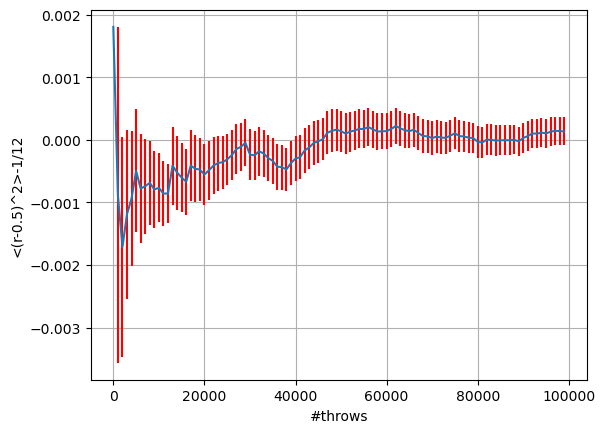

In [25]:
plt.errorbar(x, ave_prog_err-1/12, yerr=err_prog_err, ecolor='red')
plt.xlabel('#throws')
plt.ylabel('<(r-0.5)^2>-1/12')
plt.grid(True)
plt.show()

**Figure 2.** Progressive average of the second central moment (variance) of the uniform distribution as a function of the number of throws. The calculation was performed using $M = 10^5$ uniformly distributed random numbers, divided into $N = 100$ blocks, with $L = 10^3$ measurements per block.

The progressive average of the second central moment is shown as a function of the number of throws. As the number of blocks increases, the estimate progressively converges towards the theoretical value

$$
\left\langle (r-0.5)^2 \right\rangle = \frac{1}{12}.
$$

Like the first moment, the result shows that the random number generator correctly reproduces the expected second central moment of the uniform distribution.


### Chi-Squared Test

To assess the quality of the random number generator, we use the chi-squared test to quantify how well the generated numbers are compatible with a uniform distribution. The chi-squared statistic is defined as

$$
\chi^2 = \sum_{i=1}^{M} \frac{(O_i-E_i)^2}{E_i},
$$

where $O_i$ is the observed number of events in the $i$-th interval and $E_i$ is the corresponding expected number of events.

We perform $100$ independent trials. In each trial, the interval $[0,1)$ is divided into $M=100$ equally sized subintervals, and $n=10^4$ random numbers are generated. We then count the number of values falling into each subinterval, obtaining the observed frequencies $n_i$.

If the random number generator produces uniformly distributed numbers, the probability of a number falling into each subinterval is $p=1/M$. Therefore, the expected number of events in each interval is

$$
E_i = np = \frac{n}{M}.
$$

The chi-squared statistic can therefore be written as

$$
\chi^2 = \sum_{i=1}^{M}
\frac{\left(n_i-\frac{n}{M}\right)^2}{\frac{n}{M}}.
$$

The denominator $E_i$ can be understood by considering the statistical fluctuations of the number of events in each interval. The number of events $n_i$ follows a Binomial distribution,

$$
P(X=k) =
{n \choose k}p^k(1-p)^{n-k},
$$

whose mean and variance are

$$
\langle X\rangle = np,
\qquad
\sigma^2 = np(1-p).
$$

For small values of $p$, we have $1-p\simeq1$, and therefore

$$
\sigma^2 \simeq np = \langle X\rangle.
$$

Thus, the variance of the number of events is approximately equal to its expected value, which motivates the normalization by $E_i$ in the definition of $\chi^2$.

For a uniform distribution with $M$ independent intervals, the expected value of the chi-squared statistic is

$$
\langle\chi^2\rangle = M-1.
$$

The distribution of the $\chi^2$ values obtained from the $100$ independent trials can then be used to assess whether the fluctuations of the random number generator are consistent with those expected from a uniform distribution.


### Implementation of the chi-squared test

The chi-squared test was implemented through the `chi2` function in `functions.cpp`. The function takes as input the number of subintervals $n$, the number of throws per trial $m$, the number of trials $t$, and the random number generator.

For each trial, a vector of $n$ integer counters is initialized to zero. The $m$ generated random numbers are then assigned to the corresponding subinterval according to their position in $[0,1)$, and the number of events in each bin is recorded.

Once all throws have been performed, the chi-squared value is calculated by iterating over the bins and comparing the observed number of events with the expected number,

$$
E = \frac{m}{n}.
$$

The procedure is repeated for all $t$ trials. 

In [22]:
Chi2=np.loadtxt('chi2.txt')

In [23]:
dof = 99

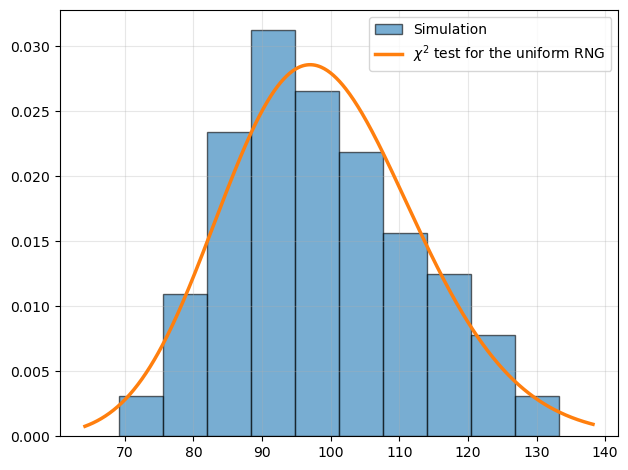

In [27]:
plt.hist(Chi2, bins=10, density=True, alpha=0.6, edgecolor='black', label='Simulation')

z = np.linspace(min(Chi2)-5, max(Chi2)+5, 500)
plt.plot(z, chi2.pdf(z, dof), linewidth=2.5, label=r'$\chi^2$ test for the uniform RNG')

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**Figure 3:** Histogram of the $\chi^2$ values obtained from $100$ independent trials, compared with the theoretical $\chi^2$ distribution with $M-1=99$ degrees of freedom. In each trial, the interval $[0,1)$ was divided into $M=100$ equally sized subintervals, and $n=10^4$ uniformly distributed random numbers were generated.

The distribution of the measured $\chi^2$ values follows the theoretical $\chi^2$ distribution reasonably well, showing that the fluctuations produced by the random number generator are broadly consistent with those expected for a uniform distribution. The histogram, however, appears to have its peak shifted towards slightly lower $\chi^2$ values compared to the theoretical distribution.

This difference can be attributed to the limited number of trials used to construct the histogram. Nevertheless, the overall agreement with the theoretical distribution is good and supports the quality of the random number generator.
